# Polymarket Prediction

Our problem is that we want to predict the future, and we will use polymarket data for that, since it has a wide variety of real world events and a big history of trades on those events, with the result resolution + we can bet and earn from it. So we will use current market sentiment towards some event, to predict if this event would come as true. To be precise it's a binary classification, for each market we predict if it would resolve to YES or NO.

For the input we wouldn't use the whole market history (since it would be resolved at that point), and instead of we use a cutoff, which will be set to 0.8, so we would predict knowing the trade history in the timeframe from market start until `(market_start + 0.8 * market_duration)`

Our metric would AUC, since we want to earn on it, and would care about having some predictions that we know are very likely to resolve in our predicted outcome and will bet on them.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

MARKETS = "markets.parquet"
QUANT = "quant.parquet"

In [2]:
markets = pd.read_parquet(MARKETS)
markets.head()

,id,question,slug,condition_id,token1,token2,answer1,answer2,closed,active,archived,outcome_prices,volume,event_id,event_slug,event_title,created_at,end_date,updated_at,neg_risk
0,1549268,"Solana Up or Down - March 11, 4:20AM-4:25AM ET",sol-updown-5m-1773217200,0x9cd234dea61536b21c39f83486f04a4623a2048acc51...,4767546158430695875598808366150003835243980254...,1066085042045672582826107627729121405230351856...,Up,Down,1,1,0,"['0', '1']",0.0,258357,sol-updown-5m-1773217200,"Solana Up or Down - March 11, 4:20AM-4:25AM ET",2026-03-10 08:26:58+00:00,2026-03-11 08:25:00+00:00,2026-04-16 00:44:20+00:00,0
1,1549269,"Bitcoin Up or Down - March 11, 4:20AM-4:25AM ET",btc-updown-5m-1773217200,0x31c8c25ea059e620d13725dfc9a76fc2765dc6229462...,1089253974122823212817645576921046983561826153...,2837944903991134182563655003756136325116775572...,Up,Down,1,1,0,"['0', '1']",0.0,258358,btc-updown-5m-1773217200,"Bitcoin Up or Down - March 11, 4:20AM-4:25AM ET",2026-03-10 08:26:58+00:00,2026-03-11 08:25:00+00:00,2026-04-16 00:44:20+00:00,0
2,1549270,"Ethereum Up or Down - March 11, 4:20AM-4:25AM ET",eth-updown-5m-1773217200,0x0addd91a134e62e17a7fccbcd87d91c4fe3a65238268...,6035928236780415169286317153369790034353481631...,4578025642926217106601512249436139282358219730...,Up,Down,1,1,0,"['0', '1']",0.0,258359,eth-updown-5m-1773217200,"Ethereum Up or Down - March 11, 4:20AM-4:25AM ET",2026-03-10 08:26:58+00:00,2026-03-11 08:25:00+00:00,2026-04-16 00:44:20+00:00,0
3,1549271,"XRP Up or Down - March 11, 4:20AM-4:25AM ET",xrp-updown-5m-1773217200,0x6ad6e9af17511c2b9886d18de07bdb61e29d689d883a...,5318462706960336500380366829828944998330958352...,1057561788821740347533567645336857636247345028...,Up,Down,1,1,0,"['0', '1']",0.0,258360,xrp-updown-5m-1773217200,"XRP Up or Down - March 11, 4:20AM-4:25AM ET",2026-03-10 08:26:58+00:00,2026-03-11 08:25:00+00:00,2026-04-16 00:44:20+00:00,0
4,1549272,Valorant: Blue Otter vs ROSE (BO3) - VCL North...,val-bo-rose-2026-03-10,0xaffa9acba8bee94acaff8b2c8b7e1c4e0caceda5acc5...,5139459777979637905857780080050994473617239618...,7817836618529119646515192221487812954963641600...,Blue Otter,ROSE,1,1,0,"['1', '0']",0.0,258361,val-bo-rose-2026-03-10,Valorant: Blue Otter vs ROSE (BO3) - VCL North...,2026-03-10 08:30:01+00:00,2026-03-11 02:00:00+00:00,2026-04-16 00:44:20+00:00,0


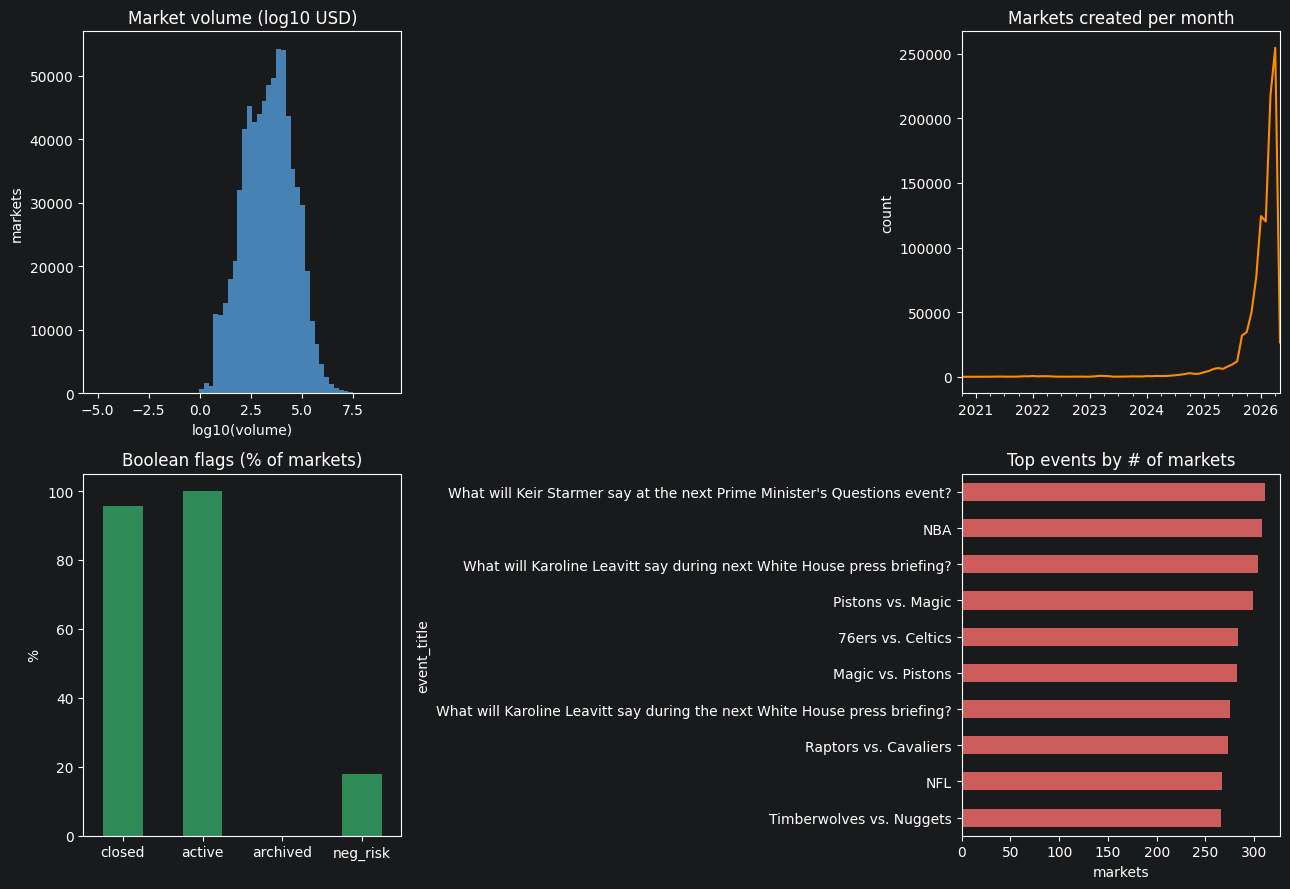

In [3]:
# Explore markets: volume distribution, creation over time, flags, biggest events.
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

v = markets.loc[markets["volume"] > 0, "volume"]
ax[0, 0].hist(np.log10(v), bins=60, color="steelblue")
ax[0, 0].set(title="Market volume (log10 USD)", xlabel="log10(volume)", ylabel="markets")

markets.set_index("created_at").resample("MS").size().plot(ax=ax[0, 1], color="darkorange")
ax[0, 1].set(title="Markets created per month", xlabel="", ylabel="count")

markets[["closed", "active", "archived", "neg_risk"]].mean().mul(100).plot.bar(ax=ax[1, 0], color="seagreen")
ax[1, 0].set(title="Boolean flags (% of markets)", ylabel="%")
ax[1, 0].tick_params(axis="x", rotation=0)

markets["event_title"].value_counts().head(10).iloc[::-1].plot.barh(ax=ax[1, 1], color="indianred")
ax[1, 1].set(title="Top events by # of markets", xlabel="markets")

fig.tight_layout()

In [4]:
# Keep only the columns used downstream (drops the uncompressible/unused ones:
# transaction_hash, block_number, log_index, condition_id, event_id, token_amount, maker, taker).
# Repetitive columns become dictionaries so the full 766M-row file fits in RAM (~22 GB).
KEEP = ["timestamp", "market_id", "price", "usd_amount", "side"]
DICT = ["market_id", "side"]

quant = pq.read_table(QUANT, columns=KEEP, read_dictionary=DICT).to_pandas()
print(f"{len(quant):,} trades | {quant.memory_usage(deep=True).sum()/1e9:.1f} GB in RAM")
print(quant.isnull().sum())
quant.head()

766,412,707 trades | 22.3 GB in RAM
timestamp     0
market_id     0
price         0
usd_amount    0
side          0
dtype: int64


,timestamp,market_id,price,usd_amount,side
0,1669680130,240380,0.52,7.80,BUY
1,1669680130,240380,0.55,1.75,BUY
2,1669680240,240380,0.51,15.30,BUY
3,1669680240,240380,0.55,3.50,BUY
4,1669682411,240380,0.50,50.00,BUY


/tmp/ipykernel_6235/234668057.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  month = pd.to_datetime(quant["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()


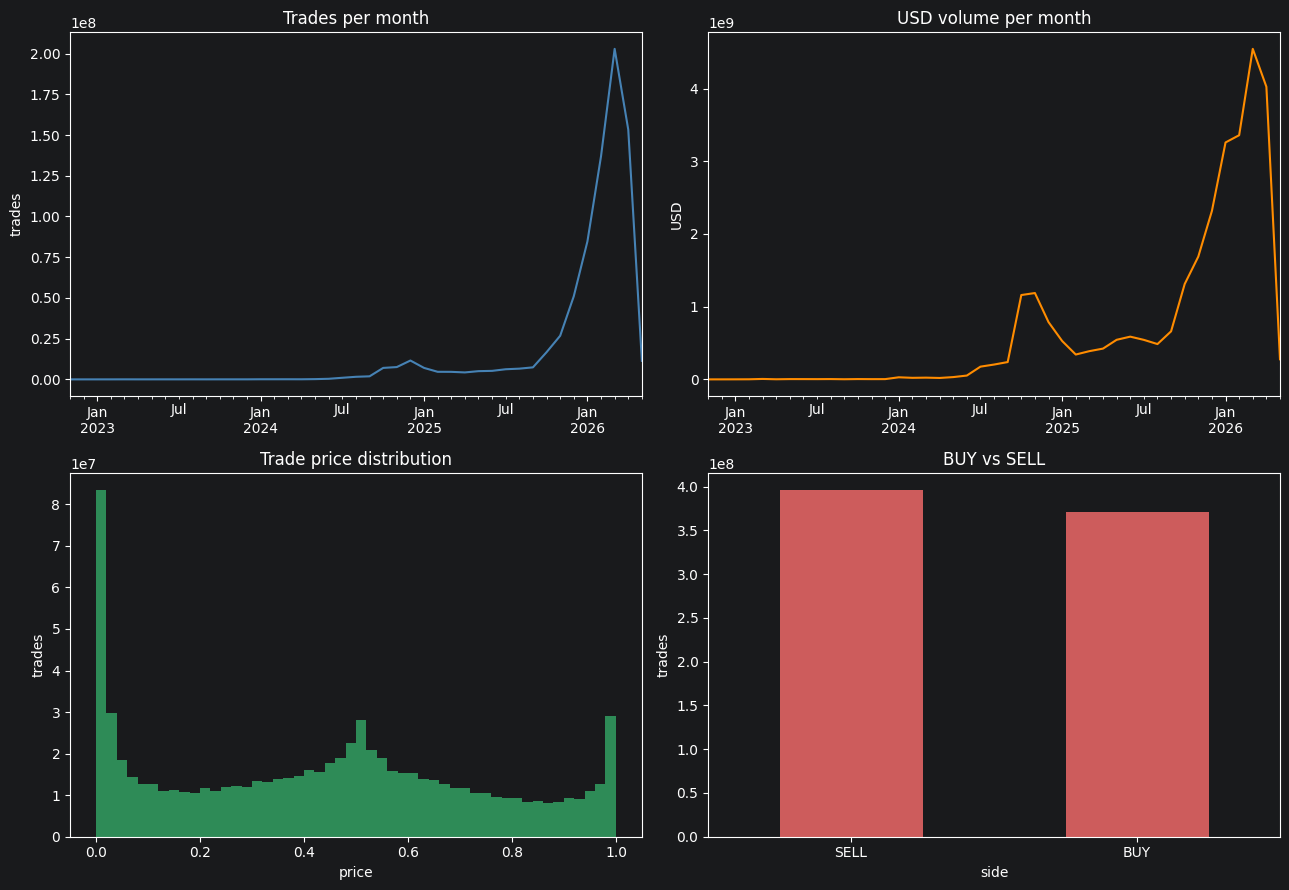

In [5]:
# Explore trades: activity over time, USD volume over time, price distribution, buy/sell split.
month = pd.to_datetime(quant["timestamp"], unit="s", utc=True).dt.to_period("M").dt.to_timestamp()
fig, ax = plt.subplots(2, 2, figsize=(13, 9))

quant.groupby(month).size().plot(ax=ax[0, 0], color="steelblue")
ax[0, 0].set(title="Trades per month", xlabel="", ylabel="trades")

quant["usd_amount"].groupby(month).sum().plot(ax=ax[0, 1], color="darkorange")
ax[0, 1].set(title="USD volume per month", xlabel="", ylabel="USD")

ax[1, 0].hist(quant["price"], bins=50, color="seagreen")
ax[1, 0].set(title="Trade price distribution", xlabel="price", ylabel="trades")

quant["side"].value_counts().plot.bar(ax=ax[1, 1], color="indianred")
ax[1, 1].set(title="BUY vs SELL", ylabel="trades")
ax[1, 1].tick_params(axis="x", rotation=0)

fig.tight_layout()

For each market we would have a cuttof_frac, this is the point of time in market life until which we take in the trades. Increasing it would allow to get more trades and be closer to the market end, which in theory should increase prediction quality

In [6]:
cutoff_frac = 0.8

### Features

For every closed market we build one row. Trades are restricted to those that happened before the `cutoff_frac` point in the market's life, so nothing leaks from the period we're trying to predict. Automated `*-updown` crypto markets are excluded (no early signal to learn from).

Target
- `label_yes` - what we predict

Market context
- `duration_hours` - market lifespan
- `has_pre_trades` - whether the market had **any** trade before the cutoff. Leak-free (only uses pre-cutoff info). It's signal in its own right: markets with no early trades resolve YES less often (~0.28 vs ~0.35). ~34% of markets have no pre-cutoff trades — we keep them rather than drop, since the missingness is informative.

(We don't use the market's full volume: `markets['volume']` is unreliable — ~32% show 0 despite having trades — and the true full volume leaks, since 87% of trades land in the last 10% of a market's life. `pre_volume` below is the leak-free, trade-derived volume.)

Trade aggregates (computed from pre-cutoff trades; `n_trades`/`pre_volume` are 0 when there were none, the `price_*` stay NaN so XGBoost/LightGBM can route the missingness)
- `n_trades` - number of trades before the cutoff
- `pre_volume` - total USD traded before the cutoff (our volume signal, computed from the trades)
- `price_mean` - average trade price
- `price_std` - population std of price or how much the price has been swinging, to get the uncertainty of the market
- `price_min` / `price_max` - lowest and highest trade prices seen; the range the market explored
- `price_last` - the most recent price before the cutoff or the market's latest estimate
- `price_drift` - `price_last − price_first`; net direction the price moved over the pre-cutoff window
- `avg_trade_usd` - mean USD size per trade, small regular transactions vs larger informed/insider trades
- `buy_frac` - share of pre-cutoff volume that was BUYs, the overall share of Yes trades


After tests decided to drop *-updown markets (bitcon up in 5m, ehtereum up in 10m) because most of the trades in this market happens in the last moments, and dropping such markets loses 42k markets with pre-cutoff trades, and 274k without cutoff trades(markets with no data in other words)

In [11]:
# Pre-cutoff trade features per closed market
EPOCH = pd.Timestamp("1970-01-01", tz="UTC")

def build_features(cutoff_frac):
    m = markets[(markets["closed"] == 1)
                & (markets["end_date"] > markets["created_at"]) # just in case
                & markets["outcome_prices"].notna()
                & ~markets["slug"].str.contains("updown", case=False, na=False)].copy()

    # label_yes = outcome_prices[0] > 0.5
    yes_price = m["outcome_prices"].str.extract(r"([-+]?\d*\.?\d+)", expand=False).astype(float)
    m["label_yes"] = yes_price > 0.5

    created_s = (m["created_at"] - EPOCH) // pd.Timedelta(seconds=1)
    end_s     = (m["end_date"]   - EPOCH) // pd.Timedelta(seconds=1)
    m["duration_hours"] = (end_s - created_s) // 3600
    m["cutoff_unix"]    = (created_s + (end_s - created_s) * cutoff_frac).astype("int64")
    m = m.rename(columns={"id": "market_id"})

    # map trades to markets using categories, to make sure it fits in ram
    cat   = quant["market_id"].cat.categories
    codes = quant["market_id"].cat.codes.to_numpy()
    cutoff_by_cat = (pd.Series(m["cutoff_unix"].values, index=m["market_id"].values)
                       .reindex(cat).to_numpy(dtype="float64"))

    trade_cutoff = cutoff_by_cat[np.where(codes >= 0, codes, 0)]
    trade_cutoff[codes < 0] = np.nan

    ts   = quant["timestamp"].to_numpy()
    keep = ts < trade_cutoff

    # ---- pre: trades before cutoff, sorted by ts
    usd = quant["usd_amount"].to_numpy()
    pre = pd.DataFrame({
        "code":    codes[keep],
        "price":   quant["price"].to_numpy()[keep],
        "usd":     usd[keep],
        "ts":      ts[keep],
        "buy_usd": np.where((quant["side"] == "BUY").to_numpy()[keep], usd[keep], 0.0),
    }).sort_values("ts", kind="stable")

    g = pre.groupby("code", sort=False)
    feat = g.agg(
        n_trades      = ("price", "size"),
        pre_volume    = ("usd",   "sum"),
        price_mean    = ("price", "mean"),
        price_min     = ("price", "min"),
        price_max     = ("price", "max"),
        price_first   = ("price", "first"),
        price_last    = ("price", "last"),
        avg_trade_usd = ("usd",   "mean"),
        buy_usd       = ("buy_usd", "sum"),
    )
    feat["price_std"]   = g["price"].std(ddof=0)
    feat["price_drift"] = feat["price_last"] - feat["price_first"]
    feat["buy_frac"]    = feat["buy_usd"] / feat["pre_volume"].replace(0, np.nan)
    feat["market_id"]   = np.asarray(cat[feat.index.to_numpy()], dtype=object)
    feat = (feat.drop(columns=["price_first", "buy_usd"])
                .set_index("market_id")
                .reindex(columns=["n_trades", "pre_volume", "price_mean", "price_std",
                                  "price_min", "price_max", "price_last", "price_drift",
                                  "avg_trade_usd", "buy_frac"]))

    out = (m[["market_id", "event_id", "slug", "label_yes", "created_at", "end_date",
              "duration_hours"]]
           .merge(feat, on="market_id", how="left"))

    out["has_pre_trades"] = out["n_trades"].notna()
    out[["n_trades", "pre_volume"]] = out[["n_trades", "pre_volume"]].fillna(0)
    return out

train = build_features(cutoff_frac)
print(f"{len(train):,} markets | "
      f"{train['has_pre_trades'].mean():.1%} have pre-cutoff trades | "
      f"label_yes={train['label_yes'].mean():.3f}")
train.head()

681,256 markets | 66.0% have pre-cutoff trades | label_yes=0.359


,market_id,event_id,slug,label_yes,created_at,end_date,duration_hours,n_trades,pre_volume,price_mean,price_std,price_min,price_max,price_last,price_drift,avg_trade_usd,buy_frac,has_pre_trades
0,1549272,258361,val-bo-rose-2026-03-10,True,2026-03-10 08:30:01+00:00,2026-03-11 02:00:00+00:00,17,41.0,1306.09,0.600927,0.271875,0.360,0.999,0.999,0.619,31.855854,0.097895,True
1,1549273,258361,val-bo-rose-2026-03-10-game1,True,2026-03-10 08:30:01+00:00,2026-03-11 00:00:00+00:00,15,10.0,101.53,0.920900,0.197062,0.330,0.999,0.999,0.669,10.153000,0.005417,True
2,1549274,258361,val-bo-rose-2026-03-10-game2,True,2026-03-10 08:30:01+00:00,2026-03-11 00:00:00+00:00,15,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,1549275,258361,val-bo-rose-2026-03-10-total-games-2pt5,False,2026-03-10 08:30:01+00:00,2026-03-11 02:00:00+00:00,17,15.0,102.47,0.022133,0.017802,0.001,0.060,0.001,-0.059,6.831333,0.000000,True
4,1549276,258361,val-bo-rose-2026-03-10-map-handicap-home-1pt5,False,2026-03-10 08:30:02+00:00,2026-03-11 02:00:00+00:00,17,8.0,0.72,0.017500,0.006614,0.010,0.030,0.010,-0.020,0.090000,0.000000,True


### Does sentiment change over a market's life? (sliding-window check)

We want to check if the market sentiment actually changes over it's lifetime, to decide if we want to have sliding windows for data in different points of market history.


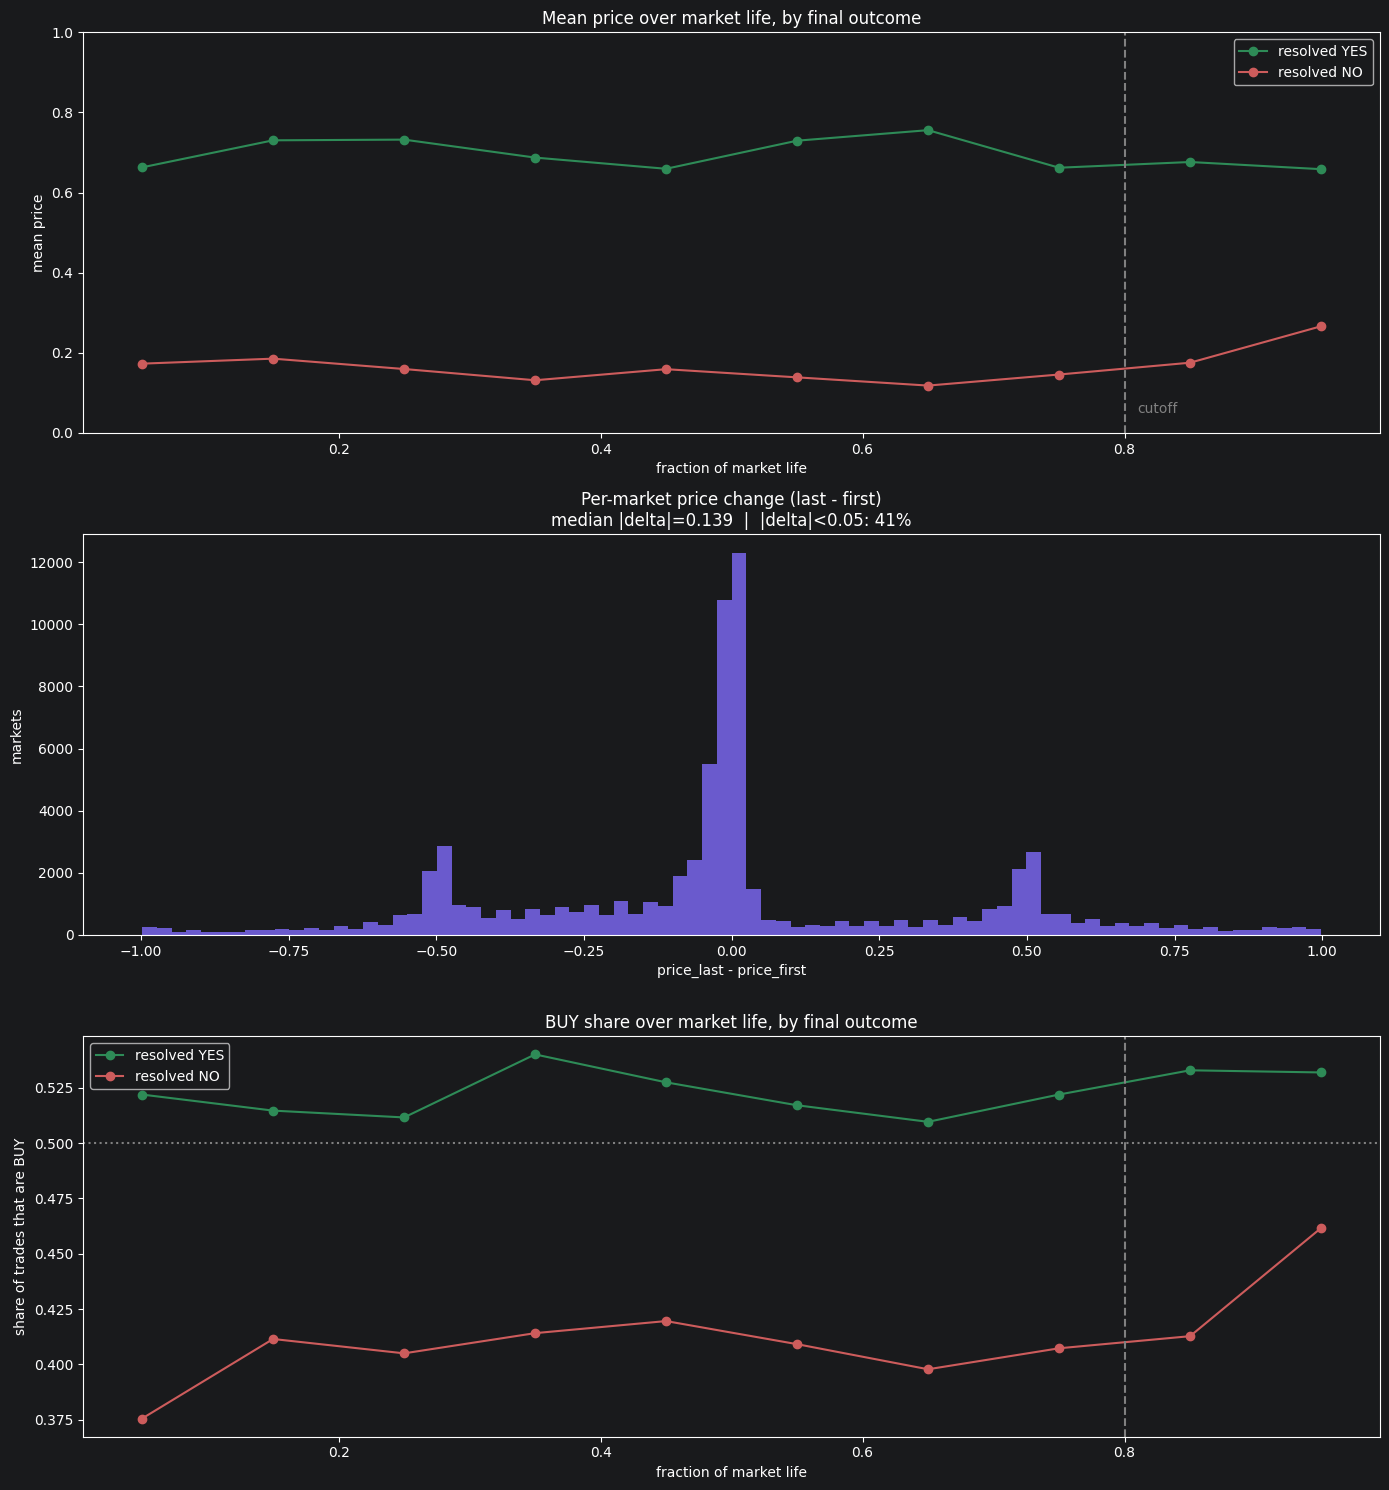

In [19]:
fig, ax = plt.subplots(3, 1, figsize=(14, 15))

# price trajectory by life-decile, split by final outcome
for lab, c in [(True, "seagreen"), (False, "indianred")]:
    gg = td[td["lab"] == lab].groupby("dec")["price"].mean().reindex(range(10))
    ax[0].plot(x, gg.values, "-o", color=c, label=f"resolved {'YES' if lab else 'NO'}")
ax[0].axvline(CUT, ls="--", color="gray"); ax[0].text(CUT + .01, 0.05, "cutoff", color="gray")
ax[0].set(title="Mean price over market life, by final outcome",
          xlabel="fraction of market life", ylabel="mean price", ylim=(0, 1)); ax[0].legend()

# per-market net sentiment change over full life
s = td.sort_values(["code", "ts"], kind="stable").groupby("code")["price"]
drift = s.last() - s.first()
ax[1].hist(drift, bins=80, color="slateblue")
ax[1].set(title=f"Per-market price change (last - first)\nmedian |delta|={drift.abs().median():.3f}  |  |delta|<0.05: {(drift.abs() < 0.05).mean():.0%}",
          xlabel="price_last - price_first", ylabel="markets")

# order-flow sentiment: BUY share over life, by outcome
for lab, c in [(True, "seagreen"), (False, "indianred")]:
    gg = td[td["lab"] == lab].groupby("dec")["buy"].mean().reindex(range(10))
    ax[2].plot(x, gg.values, "-o", color=c, label=f"resolved {'YES' if lab else 'NO'}")
ax[2].axhline(0.5, ls=":", color="gray"); ax[2].axvline(CUT, ls="--", color="gray")
ax[2].set(title="BUY share over market life, by final outcome",
          xlabel="fraction of market life", ylabel="share of trades that are BUY"); ax[2].legend()

fig.tight_layout()

It looks like on average the price is highly stable from the start of the market until the end of it. I'm leaving towards not adding additional complexity with sliding windows, despite some markets having around ~0.5 price change over their lifetime, since the majority doesn't really change.


## Getting ready to train

I will split by `end_date`, not `created_ad`, to make sure that long markets that start in train and resolve after the test/train split don't lead to data leakage

In [ ]:
df = train.copy()
df["cutoff_time"] = df["created_at"] + (df["end_date"] - df["created_at"]) * cutoff_frac

D = df["end_date"].quantile(0.8)
is_train = df["end_date"]   <  D
is_test  = df["cutoff_time"] >= D
purged   = ~(is_train | is_test)

FEATURES = ["duration_hours", "has_pre_trades", "n_trades", "pre_volume",
            "price_mean", "price_std", "price_min", "price_max",
            "price_last", "price_drift", "avg_trade_usd", "buy_frac"]
TARGET = "label_yes"

X_train, y_train = df.loc[is_train, FEATURES], df.loc[is_train, TARGET].astype(int)
X_test,  y_test  = df.loc[is_test,  FEATURES], df.loc[is_test,  TARGET].astype(int)

print(f"boundary D = {D:%Y-%m-%d %H:%M} (80th pct of end_date)")
print(f"train: {len(X_train):>7,} markets | label_yes={y_train.mean():.3f}")
print(f"test:  {len(X_test):>7,} markets | label_yes={y_test.mean():.3f}")
print(f"purged (in-flight at D): {int(purged.sum()):,}  ({purged.mean():.1%})")
train.head()

boundary D = 2026-04-12 19:30 (80th pct of end_date)
train: 544,984 markets | label_yes=0.367
test:  121,899 markets | label_yes=0.330
purged (in-flight at D): 14,373  (2.1%)


### Topical clusters as a "domain" feature

Different kinds of markets (esports, sports spreads, weather, etc) have very different markets, and that's information the numeric trade features can't capture - especially for the ~34% of markets with no pre-cutoff trades, where there's no price at all.

We cluster markets by their `slug` (which encodes both subject and bet structure) with TF-IDF + KMeans into 24 domains, and add the cluster id as a categorical feature. To avoid leakage the clusterer is fit only on the train and then applied to everything.

I chose K-Means cause I want to control the amount of clusters precisely, and maybe test different amounts later on, which is easier with K-Means, then with Dbscan and playing around with eps.
24 is just a number I thought would fit good

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans

txt = markets["slug"].fillna("")
txt.index = markets["id"].astype(str)
df["text"] = df["market_id"].map(txt).fillna("")

K_TOPICS = 24
vec = TfidfVectorizer(stop_words="english", min_df=50, max_features=4000, token_pattern=r"[a-z]{3,}")
km  = KMeans(n_clusters=K_TOPICS, random_state=42, n_init=5)
km.fit(vec.fit_transform(df.loc[is_train, "text"]))          # FIT ON TRAIN MARKETS ONLY
df["topic_cluster"] = km.predict(vec.transform(df["text"])).astype("int16")

# interpret each domain: size, base rate, top slug tokens
terms = np.array(vec.get_feature_names_out())
summ = df.groupby("topic_cluster").agg(n=("label_yes", "size"), yes_rate=("label_yes", "mean"))
for k in summ.sort_values("n", ascending=False).index:
    top = " ".join(terms[km.cluster_centers_[k].argsort()[::-1][:7]])
    print(f"c{k:2d} | n={summ.loc[k, 'n']:>7,} | yes={summ.loc[k, 'yes_rate']:.2f} | {top}")

# add as a categorical feature and rebuild the split matrices
df["topic_cluster"] = df["topic_cluster"].astype("category")
if "topic_cluster" not in FEATURES:
    FEATURES = FEATURES + ["topic_cluster"]
X_train, y_train = df.loc[is_train, FEATURES], df.loc[is_train, TARGET].astype(int)
X_test,  y_test  = df.loc[is_test,  FEATURES], df.loc[is_test,  TARGET].astype(int)
X_train.head()

c 6 | n=191,327 | yes=0.35 | game march trump week say cwbb close
c 5 | n= 47,846 | yes=0.44 | total games nfl nhl team cfb sea
c 3 | n= 36,909 | yes=0.11 | temperature highest march april london february nyc
c 9 | n= 35,477 | yes=0.43 | atp set handicap map away home total
c 4 | n= 34,745 | yes=0.40 | dota kill game liquid aur mouz tundra
c18 | n= 33,169 | yes=0.47 | nba total rebounds points okc nyk den
c21 | n= 32,753 | yes=0.35 | lol game kill teams blg jdg fox
c22 | n= 27,969 | yes=0.41 | wta match total atp set totals winner
c20 | n= 26,736 | yes=0.13 | win election tournament best awards championship open
c17 | n= 23,387 | yes=0.37 | home spread cbb nba cfb nhl nfl
c13 | n= 23,159 | yes=0.46 | april ethereum bitcoin dogecoin hype bnb reach
c 7 | n= 21,026 | yes=0.43 | cbb total champion mich tenn ark stjohn
c10 | n= 17,091 | yes=0.29 | away spread nba cbb cfb nfl nhl
c 2 | n= 16,974 | yes=0.41 | bitcoin march price october december january november
c16 | n= 16,165 | yes=0.41 | e

,duration_hours,has_pre_trades,n_trades,pre_volume,price_mean,price_std,price_min,price_max,price_last,price_drift,avg_trade_usd,buy_frac,topic_cluster
0,17,True,41.0,1306.09,0.600927,0.271875,0.360,0.999,0.999,0.619,31.855854,0.097895,6
1,15,True,10.0,101.53,0.920900,0.197062,0.330,0.999,0.999,0.669,10.153000,0.005417,6
2,15,False,0.0,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,17,True,15.0,102.47,0.022133,0.017802,0.001,0.060,0.001,-0.059,6.831333,0.000000,5
4,17,True,8.0,0.72,0.017500,0.006614,0.010,0.030,0.010,-0.020,0.090000,0.000000,9


I like how the clusters look, there is one very big generic cluster, but other clusters look alright and grouping relatively by topic.
T

## Train

For training I will use LightGBM, to build trees. My main reasons:
- always worked very good for me
- cluster is an important feature and is categorical

In [34]:
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

# Validation slice from the end of train
order = df.loc[is_train].sort_values("end_date").index
n_val = int(len(order) * 0.15)
fit_idx, val_idx = order[:-n_val], order[-n_val:]
Xf, yf = df.loc[fit_idx, FEATURES], df.loc[fit_idx, TARGET].astype(int)
Xv, yv = df.loc[val_idx, FEATURES], df.loc[val_idx, TARGET].astype(int)

model = lgb.LGBMClassifier(
    n_estimators=3000,      # just an upper cap
    learning_rate=0.1,     # default learning rate
    random_state=42,
    verbosity=-1,
)
model.fit(Xf, yf, eval_set=[(Xv, yv)], eval_metric="auc",
          callbacks=[lgb.early_stopping(50, verbose=False)])

p_test = model.predict_proba(X_test)[:, 1]

# Baseline: just use price_last; fall back to train base rate where there's no price
base_rate = yf.mean()
p_base = X_test["price_last"].fillna(base_rate).to_numpy()

def report(name, mask):
    m = np.asarray(mask)
    yt = y_test[m]
    a  = roc_auc_score(yt, p_test[m])
    ab = roc_auc_score(yt, p_base[m]) if p_base[m].std() > 0 else float("nan")  # nan = baseline can't rank
    print(f"  {name:24s} n={int(m.sum()):>6,} | model AUC={a:.4f} | baseline AUC={ab:.4f}")

print(f"best_iteration = {model.best_iteration_}")
print(f"Overall model: AUC={roc_auc_score(y_test, p_test):.4f}")
print(f"Overall price_last baseline: AUC={roc_auc_score(y_test, p_base):.4f}")
print("\nby market type:")
report("With pre-cutoff trades", X_test["has_pre_trades"].to_numpy())
report("No pre-cutoff trades",  ~X_test["has_pre_trades"].to_numpy())

print("\nfeature importance (gain):")
imp = pd.Series(model.booster_.feature_importance(importance_type="gain"), index=FEATURES)
print(imp.sort_values(ascending=False).round(0).to_string())

best_iteration = 82
Overall model: AUC=0.8955
Overall price_last baseline: AUC=0.8760

by market type:
  With pre-cutoff trades   n=75,703 | model AUC=0.9754 | baseline AUC=0.9741
  No pre-cutoff trades     n=46,196 | model AUC=0.6216 | baseline AUC=nan

feature importance (gain):
price_last        1102443.0
n_trades            75473.0
topic_cluster       36140.0
duration_hours      20091.0
price_mean          17567.0
price_max           15510.0
price_min            6004.0
pre_volume           4513.0
price_std            4214.0
price_drift          2768.0
avg_trade_usd        2537.0
buy_frac             1678.0
has_pre_trades          0.0


Looking at the gain, `price_last` completely dominates - it's фдьщые the whole model, since a market that already sits near 0 or 1 before the cutoff has pretty much told us the answer. Everything else is mostly there to help the markets where the price isn't enough

- `n_trades` - second, more trades means the price is more trustworthy, and it separates dead markets from active ones
- `topic_cluster` - the domain matters, especially for no-trade markets where there's no price at all, some topics resolve YES less often
- `duration_hours` - short and long markets behave differently, gives a signal on what kind of market it is
- `price_mean` - average price over the window, correlates with `price_last`, hence impact
- `price_max` / `price_min` - the range the price explored, small signal on top of the last price
- `pre_volume` - total USD traded, weak on its own since `price_last` already carries most of it
- `price_std` - how much the price swung, a bit of an uncertainty signal, but from graphs on top it often stays the same/similar
- `price_drift` - net direction the price moved, barely used, same as `price_std`
- `avg_trade_usd` - mean trade size, the regular and informed split, weak
- `buy_frac` - buy share, almost nothing, the price shows the same info
- `has_pre_trades` - 0 gain, the model gets the same thing from `n_trades` being 0, so it's redundant here

### How good are the most-confident predictions? (gains / lift)

The overall AUC mixes easy and hard markets. These curves rank the test markets by predicted YES probability and ask: in the top X% we're most confident about, how much better than random and than the price we do?

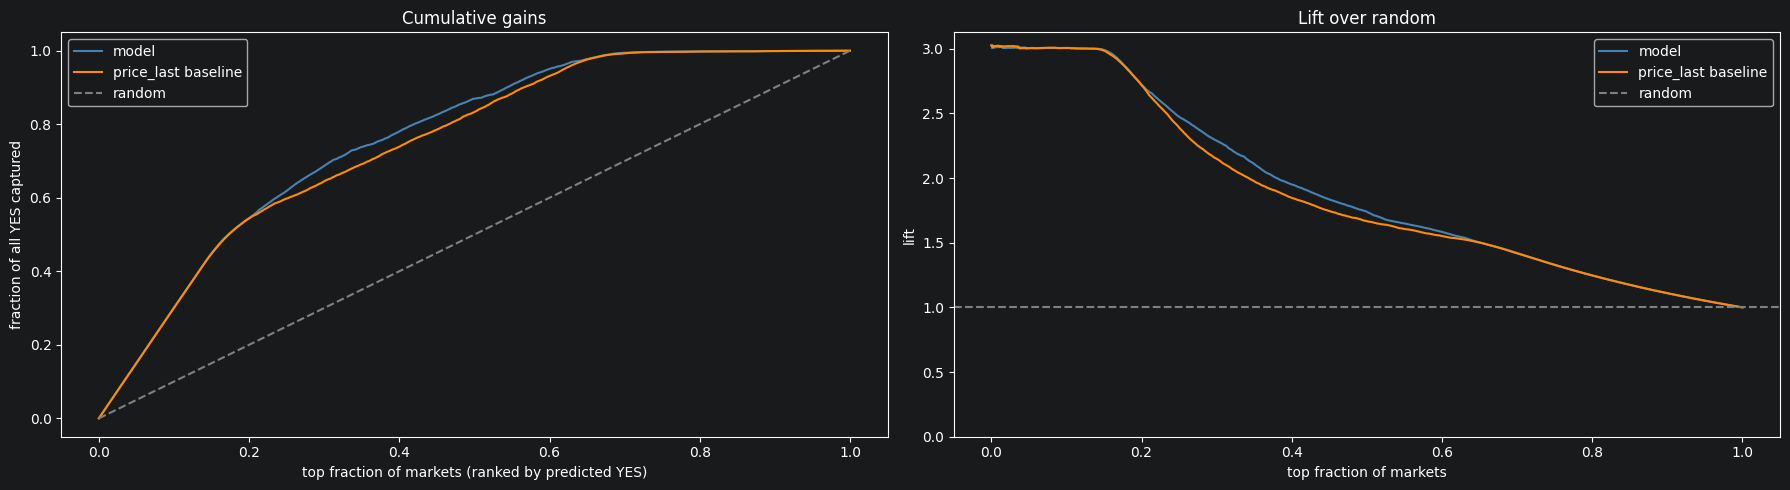

In [36]:
def gains_lift(y, p):
    y = np.asarray(y); o = np.argsort(p)[::-1]
    fp = np.arange(1, len(y) + 1) / len(y)
    cum = np.cumsum(y[o])
    g = cum / cum[-1]
    return fp, g, g / fp

fp_m, g_m, l_m = gains_lift(y_test, p_test)
fp_b, g_b, l_b = gains_lift(y_test, p_base)

fig, ax = plt.subplots(1, 2, figsize=(18, 5))
ax[0].plot(fp_m, g_m, color="steelblue", label="model")
ax[0].plot(fp_b, g_b, color="darkorange", label="price_last baseline")
ax[0].plot([0, 1], [0, 1], "--", color="gray", label="random")
ax[0].set(title="Cumulative gains", xlabel="top fraction of markets (ranked by predicted YES)",
          ylabel="fraction of all YES captured"); ax[0].legend()

ax[1].plot(fp_m, l_m, color="steelblue", label="model")
ax[1].plot(fp_b, l_b, color="darkorange", label="price_last baseline")
ax[1].axhline(1, ls="--", color="gray", label="random")
ax[1].set(title="Lift over random", xlabel="top fraction of markets", ylabel="lift", ylim=(0, None)); ax[1].legend()

fig.tight_layout()

## Prophet price-forecast feature

Prophet forecasts a series, it doesn't classify - so we use it per market: fit it on the market's pre-cutoff price history and forecast the price at resolution. That forecast will be an extra feature for LightGBM. Prophets fits are slow, so this runs on a 2500 market sample of markets with ≥10 pre-cutoff trades, and we compare LightGBM with vs without the feature on that sample's own time-split

In [38]:
from prophet import Prophet

EPOCH = pd.Timestamp("1970-01-01", tz="UTC")
N_SAMPLE, MIN_TRADES = 2500, 10

samp = df[df["n_trades"] >= MIN_TRADES].sample(N_SAMPLE, random_state=42).copy()
samp["cutoff_s"] = ((samp["created_at"] - EPOCH).dt.total_seconds()
                    + (samp["end_date"] - samp["created_at"]).dt.total_seconds() * cutoff_frac).astype("int64")
samp["end_s"] = (samp["end_date"] - EPOCH).dt.total_seconds().astype("int64")

# pull each sampled market's PRE-cutoff trades (timestamp, price) from quant
cat   = quant["market_id"].cat.categories
codes = quant["market_id"].cat.codes.to_numpy()
ts    = quant["timestamp"].to_numpy()
pos = cat.get_indexer(samp["market_id"].to_numpy()); ok = pos >= 0
in_s = np.zeros(len(cat), bool); cutoff_by_cat = np.full(len(cat), np.nan)
in_s[pos[ok]] = True; cutoff_by_cat[pos[ok]] = samp["cutoff_s"].to_numpy()[ok]
valid = codes >= 0; sel = np.zeros(len(codes), bool)
c = codes[valid]; sel[valid] = in_s[c] & (ts[valid] < cutoff_by_cat[c])
sub = pd.DataFrame({"mid": np.asarray(cat[codes[sel]], dtype=object),
                    "ts": ts[sel], "price": quant["price"].to_numpy()[sel]})

# fit Prophet per market - forecast the price at resolution
end_s_by = dict(zip(samp["market_id"], samp["end_s"]))
preds, groups = {}, list(sub.groupby("mid"))
for i, (mid_, g) in enumerate(groups):
    g = g.sort_values("ts")
    if len(g) < 5:
        continue
    series = pd.DataFrame({"ds": pd.to_datetime(g["ts"].to_numpy(), unit="s"), "y": g["price"].to_numpy()})
    try:
        pm = Prophet(weekly_seasonality=False, yearly_seasonality=False, daily_seasonality=False)
        pm.fit(series)
        yhat = pm.predict(pd.DataFrame({"ds": [pd.to_datetime(end_s_by[mid_], unit="s")]}))["yhat"].iloc[0]
        preds[mid_] = float(np.clip(yhat, 0, 1))
    except Exception:
        preds[mid_] = np.nan
    if (i + 1) % 1000 == 0:
        print(f"  fitted {i + 1}/{len(groups)} markets ...")

samp["prophet_pred"] = samp["market_id"].map(preds)
print(f"done | prophet_pred filled {samp['prophet_pred'].notna().sum():,}/{len(samp):,}")
print(f"corr(prophet_pred, price_last) = {samp[['prophet_pred', 'price_last']].corr().iloc[0, 1]:.3f}")

19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:13 - cmdstanpy - INFO - Chain [1] done processing
19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:13 - cmdstanpy - INFO - Chain [1] done processing
19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:13 - cmdstanpy - INFO - Chain [1] done processing
19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:13 - cmdstanpy - INFO - Chain [1] done processing
19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:13 - cmdstanpy - INFO - Chain [1] done processing
19:26:13 - cmdstanpy - INFO - Chain [1] start processing
19:26:14 - cmdstanpy - INFO - Chain [1] done processing
19:26:14 - cmdstanpy - INFO - Chain [1] start processing
19:26:14 - cmdstanpy - INFO - Chain [1] done processing
19:26:14 - cmdstanpy - INFO - Chain [1] start processing
19:26:14 - cmdstanpy - INFO - Chain [1] done processing
19:26:14 - cmdstanpy - INFO - Chain [1] start processing
19:26:14 - cmdstanpy - INFO - Chain [1]

  fitted 1000/2500 markets ...


19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:31 - cmdstanpy - INFO - Chain [1] done processing
19:28:31 - cmdstanpy - INFO - Chain [1] start processing
19:28:32 - cmdstanpy - INFO - Chain [1]

  fitted 2000/2500 markets ...


19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:47 - cmdstanpy - INFO - Chain [1] done processing
19:31:47 - cmdstanpy - INFO - Chain [1] start processing
19:31:50 - cmdstanpy - INFO - Chain [1] done processing
19:31:50 - cmdstanpy - INFO - Chain [1] start processing
19:31:50 - cmdstanpy - INFO - Chain [1] done processing
19:31:50 - cmdstanpy - INFO - Chain [1] start processing
19:31:50 - cmdstanpy - INFO - Chain [1] done processing
19:31:50 - cmdstanpy - INFO - Chain [1] 

done | prophet_pred filled 2,489/2,500
corr(prophet_pred, price_last) = 0.947


In [41]:
# Did the Prophet forecast add anything?
ok2 = samp["prophet_pred"].notna().to_numpy()
tr = (samp["end_date"] < D).to_numpy() & ok2
te = (samp["cutoff_time"] >= D).to_numpy() & ok2
ytr = samp.loc[tr, TARGET].astype(int)
yte = samp.loc[te, TARGET].astype(int)

def fit_auc(feats):
    mdl = lgb.LGBMClassifier(n_estimators=300, learning_rate=0.05, num_leaves=31,
                             random_state=42, n_jobs=-1, verbosity=-1)
    mdl.fit(samp.loc[tr, feats], ytr)
    return roc_auc_score(yte, mdl.predict_proba(samp.loc[te, feats])[:, 1])

p_last = samp.loc[te, "price_last"].fillna(ytr.mean()).clip(0, 1)
print(f"sample ablation | train={int(tr.sum()):,}  test={int(te.sum()):,}")
print(f"  price_last baseline    AUC = {roc_auc_score(yte, p_last):.4f}")
print(f"  prophet_pred alone     AUC = {roc_auc_score(yte, samp.loc[te, 'prophet_pred']):.4f}")
print(f"  LightGBM (no prophet)  AUC = {fit_auc(FEATURES):.4f}")
print(f"  LightGBM (+ prophet)   AUC = {fit_auc(FEATURES + ['prophet_pred']):.4f}")

sample ablation | train=2,058  test=345
  price_last baseline    AUC = 0.9674
  prophet_pred alone     AUC = 0.9571
  LightGBM (no prophet)  AUC = 0.9591
  LightGBM (+ prophet)   AUC = 0.9627


Prophet didn't improve the model noticably, the difference is within noise, and the correlation of prophet predicted price with pre-cutoff `price_last` is ~0.95, so they are almost equal.